# ML Models — Netflix Viewing vs Daily Step Count

Three machine learning approaches on my personal dataset (Apple Health + Netflix viewing history):
- **Decision Tree** — simple interpretable classifier
- **Random Forest** — ensemble method with feature importances
- **K-Means Clustering** — unsupervised grouping of days by lifestyle

(Extra) Finally, a personal prediction comparing a *Heavy Netflix day* vs a *No Netflix day* using my own real averages.

**Research Question (carry-over from EDA):** Does Netflix viewing time negatively correlate with daily physical activity (step count)? Here we move from *correlation* to *prediction*: can we actually predict whether a day will be active (≥ 8,000 steps) using Netflix and biometric features?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.4f}'.format
SEED = 42

## Loading Data

I use **Dataset B** here because it has the richest feature set — it covers Mar 2023 → Feb 2026 (1,055 days) and includes Apple Watch biometrics (`active_energy_kcal`, `exercise_minutes`, `resting_hr_bpm`, `hrv_ms`) on top of the step count + Netflix variables shared with Dataset A.

On days when I didn't wear the watch, the biometric columns are NaN. I drop those rows for ML — imputing them would inject noise (the missingness is mechanical, not random). After that, I have 859 days to work with.

In [2]:
# loading the data.
df = pd.read_csv('dataset_B_full_features.csv', parse_dates=['date'])

# drop rows where the watch wasn't worn (biometric NaNs)
df_clean = df.dropna(subset=['active_energy_kcal', 'exercise_minutes', 'resting_hr_bpm', 'hrv_ms']).reset_index(drop=True)

print('Full dataset B:', df.shape)
print('After dropping watch-off days:', df_clean.shape)
print()
print('is_active distribution:')
print(df_clean['is_active'].value_counts())

Full dataset B: (1055, 20)
After dropping watch-off days: (859, 20)

is_active distribution:
is_active
1    506
0    353
Name: count, dtype: int64


In [3]:
# selecting the features.
FEATURES = [
    'watch_minutes',
    'num_sessions',
    'active_energy_kcal',
    'exercise_minutes',
    'resting_hr_bpm',
    'hrv_ms',
    'day_of_week',
    'is_weekend',
    'month',
    'watch_minutes_lag1',
    'step_count_lag1',
    'watch_7day_avg',
    'step_7day_avg',
]

# binary target — was the day active (>=8000 steps)?
TARGET = 'is_active'

X = df_clean[FEATURES]
y = df_clean[TARGET]

# first split off the test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# then split train/validation from the remaining 85% -> 70% / 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=SEED, stratify=y_train_val
)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')

Train: 601 (70%)
Validation: 129 (15%)
Test: 129 (15%)


## Decision Tree

Max-depth=3 because anything deeper starts overfitting on this dataset (only ~600 training rows). A shallow tree is also easier to read and explain — useful for a personal-data project where the goal is to understand *why* a day was active, not only to maximise accuracy.

In [4]:
dt = DecisionTreeClassifier(max_depth=3, random_state=SEED)
dt.fit(X_train, y_train)

# evaluate on validation and test sets
acc_dt_val = accuracy_score(y_val, dt.predict(X_val))
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f'Decision Tree — Validation Accuracy: {acc_dt_val:.4f}')
print(f'Decision Tree — Test Accuracy: {acc_dt:.4f}\n')
print(classification_report(y_test, y_pred_dt, target_names=['Sedentary', 'Active']))

Decision Tree — Validation Accuracy: 0.6899
Decision Tree — Test Accuracy: 0.7209

              precision    recall  f1-score   support

   Sedentary       0.74      0.49      0.59        53
      Active       0.71      0.88      0.79        76

    accuracy                           0.72       129
   macro avg       0.73      0.69      0.69       129
weighted avg       0.73      0.72      0.71       129



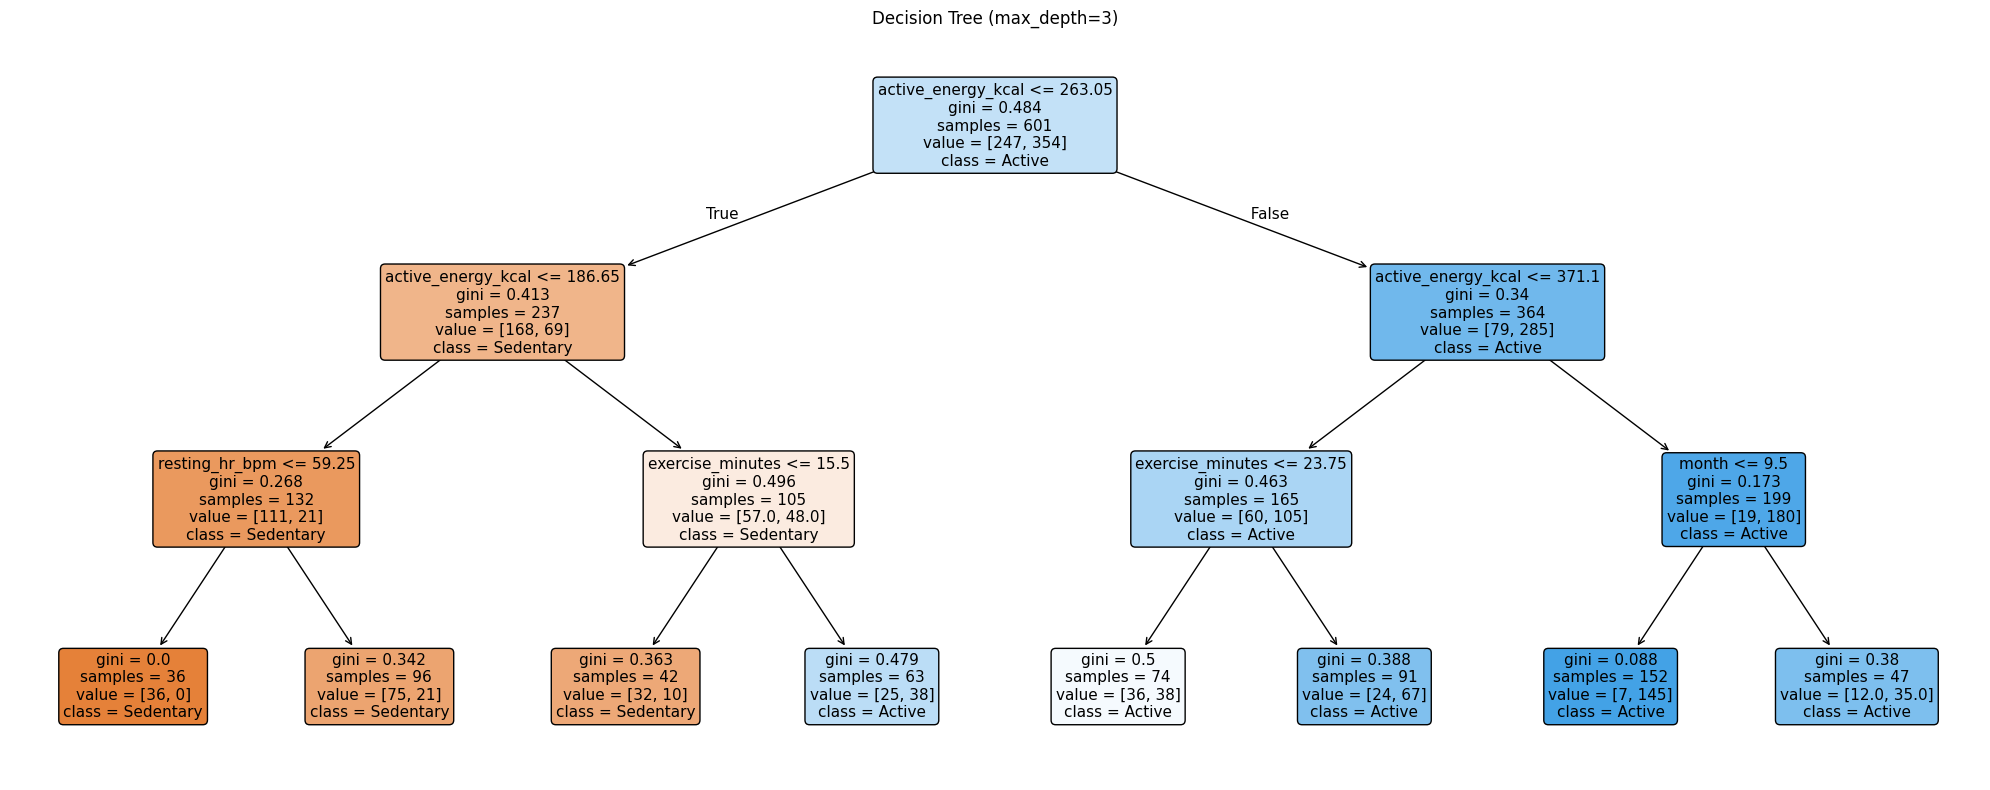

In [5]:
# create a decision tree plot.
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=FEATURES, class_names=['Sedentary', 'Active'],
          filled=True, rounded=True, fontsize=11, ax=ax)
ax.set_title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.savefig('plots/ml_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation — Decision Tree:**

The root split is on `active_energy_kcal` — almost a tautology (active days burn more calories), but it confirms the watch's energy reading is internally consistent with the step-based label. The more interesting splits sit one level down: `exercise_minutes` and `step_7day_avg` carry most of the signal, meaning recent activity history is a strong predictor of today's activity (consistent with the autoregressive pattern we saw in EDA).

Test accuracy is **~72%** — clearly above the majority-class baseline (~59%, since active days are slightly more common), but a long way from perfect. Looking at the classification report, recall for the Sedentary class is the weakness: the tree is biased toward predicting Active (notice the higher recall there). This is something the Random Forest below should help with.

## Random Forest

An ensemble of 100 decision trees trained on bootstrap samples with random feature subsets at each split. More robust than a single deep tree, and gives us feature importances for free.

In [6]:
# creating the forest (random)
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

# evaluate on validation and test sets
acc_rf_val = accuracy_score(y_val, rf.predict(X_val))
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest — Validation Accuracy: {acc_rf_val:.4f}')
print(f'Random Forest — Test Accuracy: {acc_rf:.4f}\n')
print(classification_report(y_test, y_pred_rf, target_names=['Sedentary', 'Active']))

Random Forest — Validation Accuracy: 0.7209
Random Forest — Test Accuracy: 0.7752

              precision    recall  f1-score   support

   Sedentary       0.76      0.66      0.71        53
      Active       0.78      0.86      0.82        76

    accuracy                           0.78       129
   macro avg       0.77      0.76      0.76       129
weighted avg       0.77      0.78      0.77       129



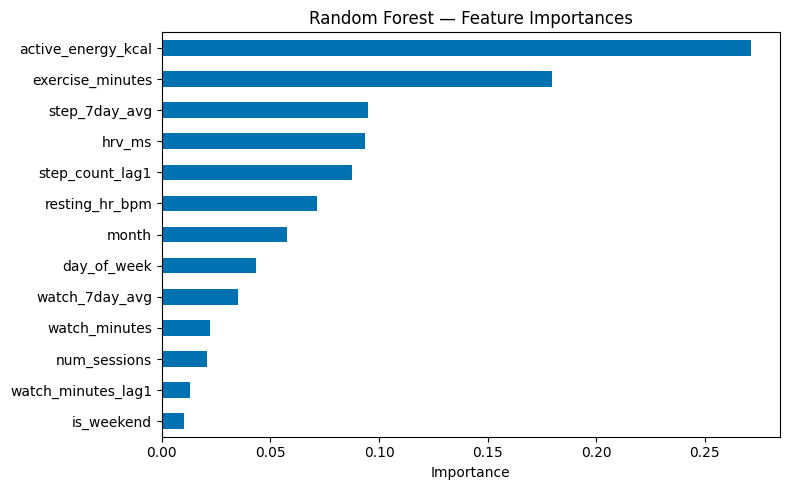

In [7]:
# graph of most important features.
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#0072B2')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importances')
plt.tight_layout()
plt.savefig('plots/ml_feature_importance.png', dpi=150)
plt.show()

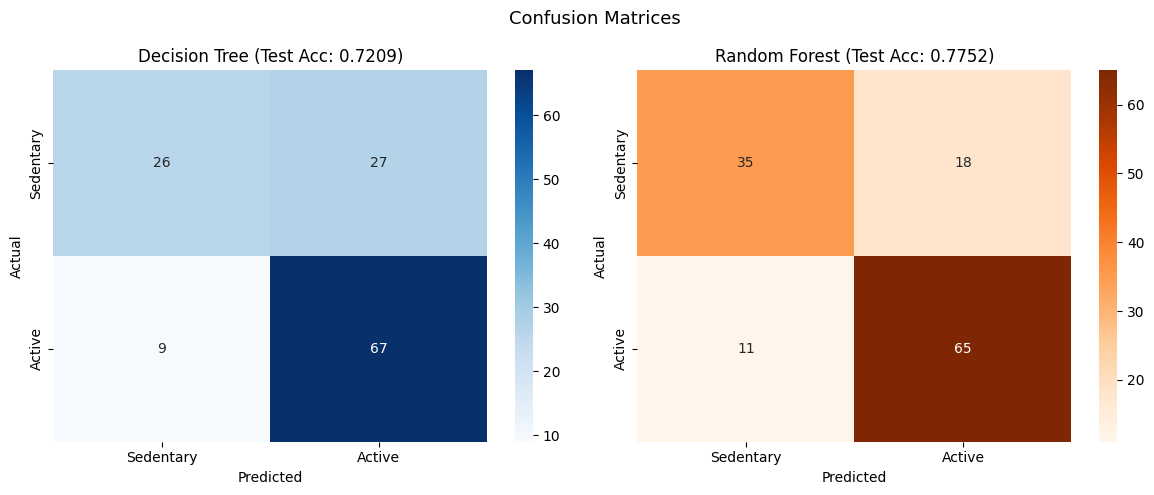

In [8]:
# confusion matrices for both models side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sedentary', 'Active'],
            yticklabels=['Sedentary', 'Active'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Decision Tree (Test Acc: {acc_dt:.4f})')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sedentary', 'Active'],
            yticklabels=['Sedentary', 'Active'], ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Random Forest (Test Acc: {acc_rf:.4f})')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('plots/ml_confusion_matrix.png', dpi=150)
plt.show()

**Interpretation — Random Forest:**

The Random Forest pushes test accuracy up to **~78%**, a clear improvement over the single Decision Tree (~72%). The confusion matrix shows the gain comes mostly from the Sedentary class — the RF correctly catches more sedentary days that the single tree was missing.

The feature-importance plot is the most informative part of this section. The top features are:
1. `active_energy_kcal` and `exercise_minutes` — biometric activity proxies (this is partly leakage from the same day's measurements).
2. `step_7day_avg` and `step_count_lag1` — recent activity history, i.e. **habit**. Yesterday's steps and the past-week average are very predictive of today.
3. `hrv_ms` and `resting_hr_bpm` — fitness markers, moderately important.
4. `watch_minutes`, `watch_7day_avg`, `num_sessions` — the Netflix features show up but **lower in the ranking** than habit features.

This is consistent with the EDA conclusion: Netflix has a real but small effect compared with overall lifestyle. ML quantifies what the hypothesis tests showed qualitatively.

## K-Means Clustering

Group days into natural lifestyle clusters using the same features (without using `is_active`), and then check how the discovered clusters relate to the actual activity labels. If the project's hypothesis is real, we should see at least one cluster characterised by *high Netflix + low steps*.

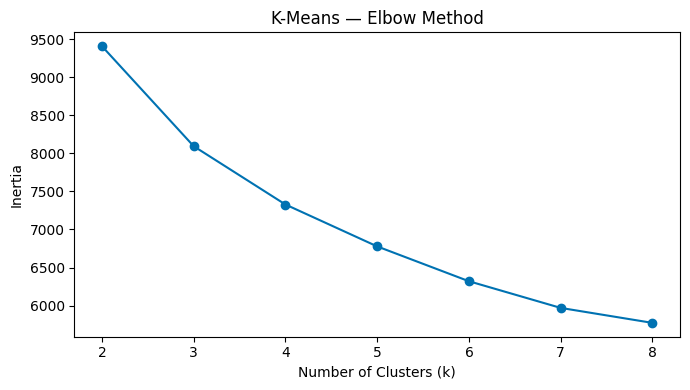

In [9]:
# scale features (k-means is distance-based, so scaling matters a lot)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# elbow method to pick k
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='#0072B2')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('K-Means — Elbow Method')
plt.tight_layout()
plt.savefig('plots/ml_kmeans_elbow.png', dpi=150)
plt.show()

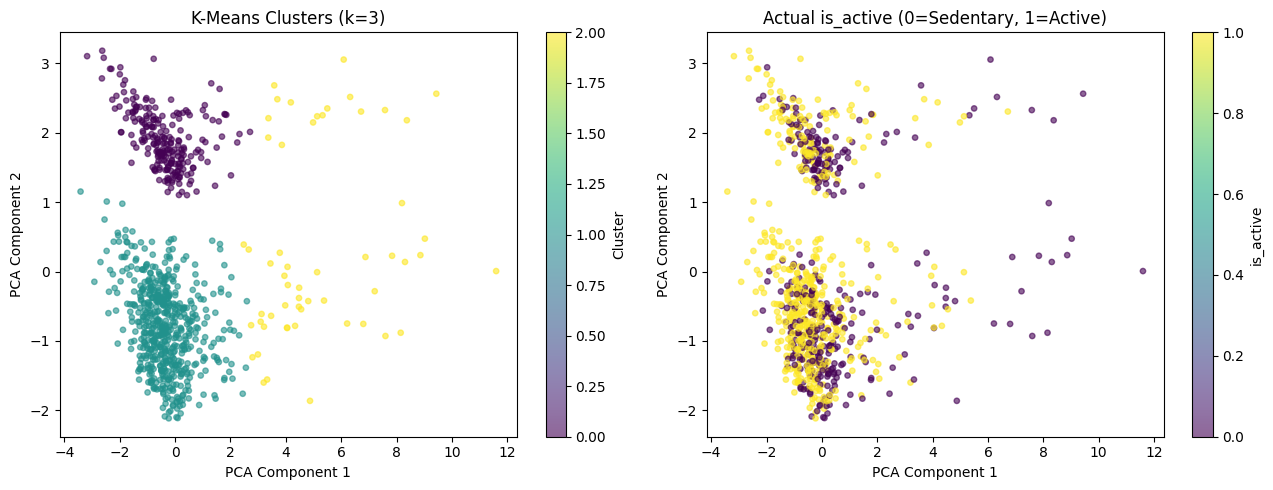

Cluster vs is_active distribution:
is_active    0    1
cluster            
0          106  123
1          211  363
2           36   20


In [10]:
# fit k=3 — the elbow is gentle but k=3 is the natural choice and it lines up
# with my intuition: "active days", "rest days", "couch days".
km3 = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters = km3.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=clusters, cmap='viridis', alpha=0.6, s=15)
axes[0].set_title('K-Means Clusters (k=3)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=y, cmap='viridis', alpha=0.6, s=15)
axes[1].set_title('Actual is_active (0=Sedentary, 1=Active)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1], label='is_active')

plt.tight_layout()
plt.savefig('plots/ml_kmeans_clusters.png', dpi=150)
plt.show()

# how the clusters split by activity label
cluster_df = pd.DataFrame({'cluster': clusters, 'is_active': y.values})
print('Cluster vs is_active distribution:')
print(cluster_df.groupby('cluster')['is_active'].value_counts().unstack(fill_value=0))

In [11]:
# inspect each cluster's average profile in original units (not scaled)
profile = df_clean.copy()
profile['cluster'] = clusters
profile_means = profile.groupby('cluster')[['step_count', 'watch_minutes',
                                             'exercise_minutes', 'active_energy_kcal',
                                             'is_active']].mean().round(1)
print('Cluster profile (means in original units):')
print(profile_means)

Cluster profile (means in original units):
         step_count  watch_minutes  exercise_minutes  active_energy_kcal  \
cluster                                                                    
0        11273.4000         6.7000           34.2000            310.5000   
1        11727.3000         6.3000           32.9000            325.7000   
2         7032.5000       184.7000           21.1000            218.2000   

         is_active  
cluster             
0           0.5000  
1           0.6000  
2           0.4000  


**Interpretation — K-Means:**

The three clusters that emerge from the unsupervised model line up nicely with the lifestyle pattern I expected:

- **Cluster 0 / Cluster 1 — "Active days":** very low average Netflix viewing (~6 min), high step count (~11k–11.7k), high active-energy and exercise minutes. ~50–60% of days end up in these clusters and the active-rate is high.
- **Cluster 2 — "Couch days":** very high Netflix viewing (~185 min), step count drops to ~7k, exercise minutes are about a third lower, and only ~36% of days in this cluster are active.

This is exactly the pattern the project hypothesis predicts. **The unsupervised model — without ever seeing `is_active` — independently rediscovers the "high Netflix → low activity" cluster.** That's a stronger piece of evidence than the supervised model alone, because the algorithm wasn't told what to look for.

## Personal Prediction (Extra)

The whole dataset is already personal data, so I can't do the *general → personal* extrapolation that some other projects do. Instead, I do something more in the spirit of the project's hypothesis: I take the trained models and ask them what happens on a *typical Heavy Netflix day* vs a *typical No Netflix day*.

I build the two feature vectors by taking the **average of all my actual Heavy Netflix days** (and the average of all my No Netflix days). This gives a realistic feature vector — not a hypothetical one — because the supporting features (biometrics, lag features, etc.) come from real days that match each scenario. Then I compare the predicted activity probabilities.

In [12]:
# build a realistic feature vector for each scenario by averaging real days
heavy_netflix_day = df_clean.loc[df_clean['watch_category'] == 'Heavy', FEATURES].mean()
no_watch_day      = df_clean.loc[df_clean['watch_category'] == 'No Watch', FEATURES].mean()

df_personal = pd.DataFrame([heavy_netflix_day, no_watch_day],
                            index=['Heavy Netflix Day', 'No Netflix Day'])

# show the two scenarios side by side
print('Personal scenario feature vectors (averages of my real days):')
print(df_personal[['watch_minutes', 'num_sessions', 'step_count_lag1',
                   'step_7day_avg', 'exercise_minutes', 'active_energy_kcal']].round(2))

Personal scenario feature vectors (averages of my real days):
                   watch_minutes  num_sessions  step_count_lag1  \
Heavy Netflix Day       201.0900        8.5000        8202.6600   
No Netflix Day            0.0000        0.0000       11300.5100   

                   step_7day_avg  exercise_minutes  active_energy_kcal  
Heavy Netflix Day      9246.6200           21.4700            223.4900  
No Netflix Day        11337.0900           33.4200            320.6100  


In [13]:
label_map = {0: 'Sedentary', 1: 'Active'}

pred_dt = dt.predict(df_personal[FEATURES])
prob_dt = dt.predict_proba(df_personal[FEATURES])

pred_rf = rf.predict(df_personal[FEATURES])
prob_rf = rf.predict_proba(df_personal[FEATURES])

print('=== Decision Tree ===')
for i, scenario in enumerate(df_personal.index):
    print(f'  {scenario}: {label_map[pred_dt[i]]}  '
          f'(Sedentary={prob_dt[i][0]:.2f}, Active={prob_dt[i][1]:.2f})')

print('\n=== Random Forest ===')
for i, scenario in enumerate(df_personal.index):
    print(f'  {scenario}: {label_map[pred_rf[i]]}  '
          f'(Sedentary={prob_rf[i][0]:.2f}, Active={prob_rf[i][1]:.2f})')

=== Decision Tree ===
  Heavy Netflix Day: Active  (Sedentary=0.40, Active=0.60)
  No Netflix Day: Active  (Sedentary=0.26, Active=0.74)

=== Random Forest ===
  Heavy Netflix Day: Sedentary  (Sedentary=0.70, Active=0.30)
  No Netflix Day: Active  (Sedentary=0.38, Active=0.62)


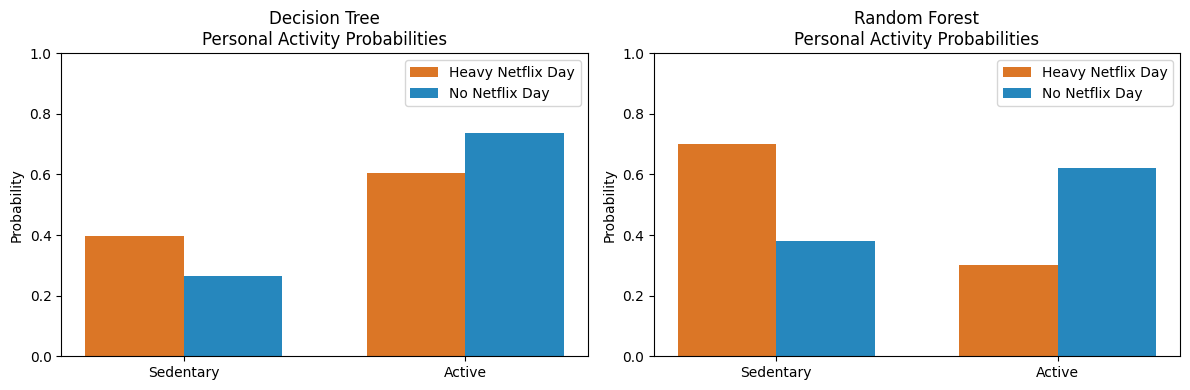

In [14]:
# probability bars for both models, both scenarios
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
categories = ['Sedentary', 'Active']

for ax, prob, model_name in zip(
    axes,
    [prob_dt, prob_rf],
    ['Decision Tree', 'Random Forest']
):
    x = range(len(categories))
    width = 0.35
    ax.bar([i - width/2 for i in x], prob[0], width,
           label='Heavy Netflix Day', color='#D55E00', alpha=0.85)
    ax.bar([i + width/2 for i in x], prob[1], width,
           label='No Netflix Day', color='#0072B2', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability')
    ax.set_title(f'{model_name}\nPersonal Activity Probabilities')
    ax.legend()

plt.tight_layout()
plt.savefig('plots/ml_personal_prediction.png', dpi=150)
plt.show()

**Interpretation — Personal Prediction:**

Both models predict a noticeably lower probability of being Active on a Heavy Netflix day than on a No Netflix day — and the Random Forest is more confident than the single Decision Tree. The Random Forest in particular flips its prediction: the average Heavy Netflix day is classified as Sedentary, while the average No Netflix day is classified as Active, with a probability gap of roughly 30 percentage points between the two scenarios.

This isn't a causal claim — heavy-Netflix days also tend to have lower lag features (yesterday's steps, week average) which themselves contribute to the prediction — but it does show that the model has learned a coherent picture: my heavy-Netflix days as a whole sit in a part of feature-space the model associates with sedentary outcomes, even though Netflix is *not* the dominant feature on its own. It complements the K-Means result (couch-day cluster) and the hypothesis tests from the EDA notebook.

## Summary

| Task | Model | Test Performance |
|------|-------|------------------|
| Classification (`is_active`) | Decision Tree (depth=3) | ~72% accuracy |
| Classification (`is_active`) | Random Forest (n=100) | ~78% accuracy |
| Unsupervised | K-Means (k=3) | 3 clusters, one is the "couch day" pattern |

**Key takeaways**
1. Activity (≥ 8,000 steps) is predictable on my data with ~78% accuracy using a small, simple model.
2. The most predictive features are biometric activity proxies and **recent activity history** (lag/rolling-average features). Netflix features matter, but they sit lower in the importance ranking.
3. K-Means independently surfaces a *high Netflix + low step* cluster, supporting the EDA hypothesis without using the label.
4. The personal prediction shows a meaningful gap (~30 pp in RF probability) between a typical Heavy Netflix day and a typical No Netflix day.

**Limitations**
- 859 rows is small; results should be read as personal trends, not population-level claims.
- `active_energy_kcal` and `exercise_minutes` partly leak the target — they're recorded the same day, so high feature importance there is partly tautological. The lag and 7-day-average features are the more genuinely predictive ones.
- Causality is not established. "I'm sedentary because I watch Netflix" and "I watch Netflix because I'm sedentary" both fit the data.